# Challenge Data ENS #163 — Egis : Prédisez les infractions de stationnement

**Contexte** : Egis, entreprise française d'ingénierie des infrastructures, déploie des capteurs de comptage de trafic routier sur l'ensemble du territoire. Ces capteurs enregistrent des données de flux (nombre de véhicules) mais produisent parfois des mesures invalides en raison des conditions météorologiques, de pannes, ou d'anomalies de calibration.

**Objectif** : Prédire le ratio de mesures invalides (`invalid_ratio` ∈ [0, 1]) à partir de caractéristiques de localisation, météorologiques et temporelles.

**Métrique d'évaluation** : Corrélation de Spearman (rank-based) — la qualité du modèle dépend de sa capacité à **ordonner correctement** les observations, pas à prédire les valeurs exactes.

---
**Features disponibles** :
| Feature | Description |
|---|---|
| `total_count` | Nombre total de mesures sur la période |
| `longitude_scaled` | Longitude normalisée [0,1] |
| `latitude_scaled` | Latitude normalisée [0,1] |
| `Precipitations` | Précipitations (mm) |
| `HauteurNeige` | Hauteur de neige (cm) |
| `Temperature` | Température (°C) |
| `ForceVent` | Force du vent |
| `day_of_week` | Jour de la semaine (0=Lundi, 6=Dimanche) |
| `month_of_year` | Mois de l'année (1–12) |
| `hour` | Heure de la journée (0–23) |

Auteur : **Motawassim LAHMADI**

## 1. Setup & Chargement des données

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from scipy.stats import spearmanr, rankdata
from sklearn.model_selection import KFold
from sklearn.preprocessing import LabelEncoder
import lightgbm as lgb
import os

# Style des graphiques
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
SEED = 42
np.random.seed(SEED)

In [18]:
print('Chargement des données...')
x_train = pd.read_csv("../data/x_train_final_asAbTs5.csv", index_col=0)
y_train = pd.read_csv('../data/y_train_final_YYyFil7.csv', index_col=0)
x_test  = pd.read_csv('../data/x_test_final_fIrnA7Q.csv',  index_col=0)

print(f'x_train : {x_train.shape}  |  y_train : {y_train.shape}')
print(f'x_test  : {x_test.shape}')

Chargement des données...
x_train : (6076546, 10)  |  y_train : (6076546, 1)
x_test  : (2028750, 10)


## 2. Exploration des données (EDA)

In [7]:
# Vue d'ensemble
print('=== APERÇU DES FEATURES ===' )
display(x_train.head())
print('\n=== STATISTIQUES DESCRIPTIVES ===')
display(x_train.describe().round(3))
print('\n=== VALEURS MANQUANTES ===')
print(x_train.isnull().sum())

=== APERÇU DES FEATURES ===


,total_count,longitude_scaled,latitude_scaled,Precipitations,HauteurNeige,Temperature,ForceVent,day_of_week,month_of_year,hour
0,1,0.998417,0.996118,0.0,0.0,14.6,2.5,3,4,8
1,35,0.999222,0.996000,0.0,0.0,22.4,3.1,5,3,13
2,3,0.998371,0.996309,1.8,0.0,11.7,3.3,4,10,8
3,1,0.998804,0.996343,0.0,0.0,28.6,2.6,4,2,16
4,2,0.999126,0.996417,0.0,0.0,9.6,3.2,3,9,18



=== STATISTIQUES DESCRIPTIVES ===


,total_count,longitude_scaled,latitude_scaled,Precipitations,HauteurNeige,Temperature,ForceVent,day_of_week,month_of_year,hour
count,6076546.000,6076546.000,6076546.000,6076546.000,5912530.000,6076546.000,6070464.000,6076546.000,6076546.000,6076546.000
mean,8.686,0.999,0.996,0.113,0.004,15.201,3.356,3.531,6.562,12.258
std,11.636,0.001,0.008,0.572,0.065,6.935,1.486,1.707,3.464,3.178
min,1.000,0.000,0.000,0.000,0.000,-3.600,0.000,1.000,1.000,6.000
25%,1.000,0.999,0.996,0.000,0.000,10.500,2.200,2.000,4.000,9.000
50%,4.000,0.999,0.996,0.000,0.000,14.500,3.200,4.000,7.000,12.000
75%,11.000,0.999,0.996,0.000,0.000,20.100,4.200,5.000,10.000,15.000
max,1669.000,1.000,1.000,23.600,1.000,35.300,10.500,6.000,12.000,19.000



=== VALEURS MANQUANTES ===
total_count              0
longitude_scaled         0
latitude_scaled          0
Precipitations           0
HauteurNeige        164016
Temperature              0
ForceVent             6082
day_of_week              0
month_of_year            0
hour                     0
dtype: int64


In [19]:
print('=== APERÇU DE Y_TRAIN ===' )
display(y_train.head())
print('\n=== VALEURS MANQUANTES ===')
print(y_train.isnull().sum())

=== APERÇU DE Y_TRAIN ===


,invalid_ratio
0,0.000000
1,0.228571
2,1.000000
3,0.000000
4,0.500000



=== VALEURS MANQUANTES ===
invalid_ratio    0
dtype: int64


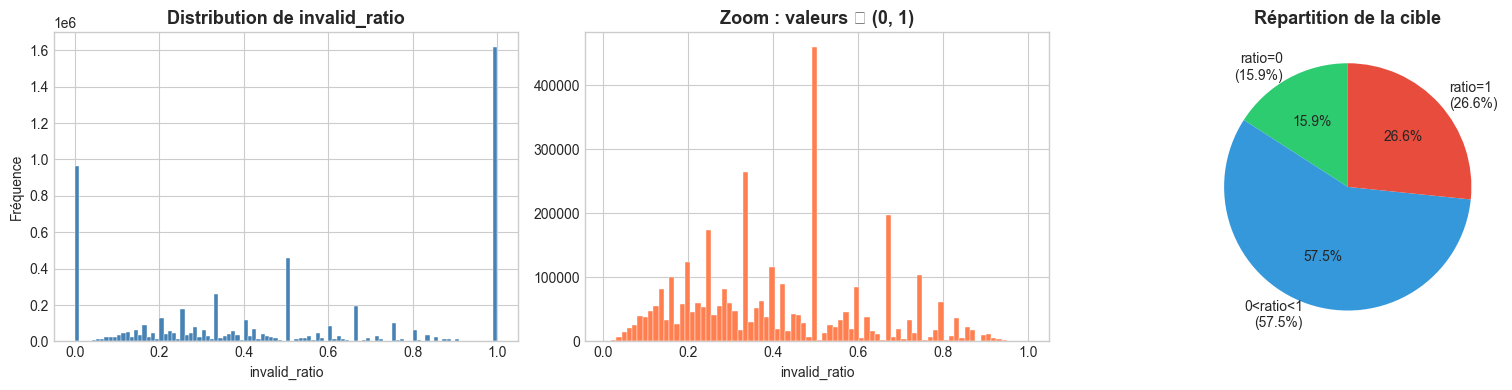

Moyenne   : 0.5024
Médiane   : 0.4615
Std       : 0.3684
% de zéros: 15.90%
% de uns  : 26.62%


In [21]:
y_train = y_train.squeeze()

# Distribution de la cible
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Histogramme complet
axes[0].hist(y_train, bins=100, color='steelblue', edgecolor='white', linewidth=0.3)
axes[0].set_title('Distribution de invalid_ratio', fontsize=13, fontweight='bold')
axes[0].set_xlabel('invalid_ratio')
axes[0].set_ylabel('Fréquence')

# Zoom sur les valeurs intermédiaires (excluant 0 et 1)
mask_mid = (y_train > 0) & (y_train < 1)
axes[1].hist(y_train[mask_mid], bins=80, color='coral', edgecolor='white', linewidth=0.3)
axes[1].set_title('Zoom : valeurs ∈ (0, 1)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('invalid_ratio')

# Pie chart des cas extrêmes
pct_zero = (y_train == 0).mean() * 100
pct_one  = (y_train == 1).mean() * 100
pct_mid  = 100 - pct_zero - pct_one
axes[2].pie(
    [pct_zero, pct_mid, pct_one],
    labels=[f'ratio=0\n({pct_zero:.1f}%)', f'0<ratio<1\n({pct_mid:.1f}%)', f'ratio=1\n({pct_one:.1f}%)'],
    colors=['#2ecc71', '#3498db', '#e74c3c'],
    autopct='%1.1f%%', startangle=90
)
axes[2].set_title('Répartition de la cible', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('../DataViz/target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Moyenne   : {y_train.mean():.4f}')
print(f'Médiane   : {y_train.median():.4f}')
print(f'Std       : {y_train.std():.4f}')
print(f'% de zéros: {pct_zero:.2f}%')
print(f'% de uns  : {pct_one:.2f}%')

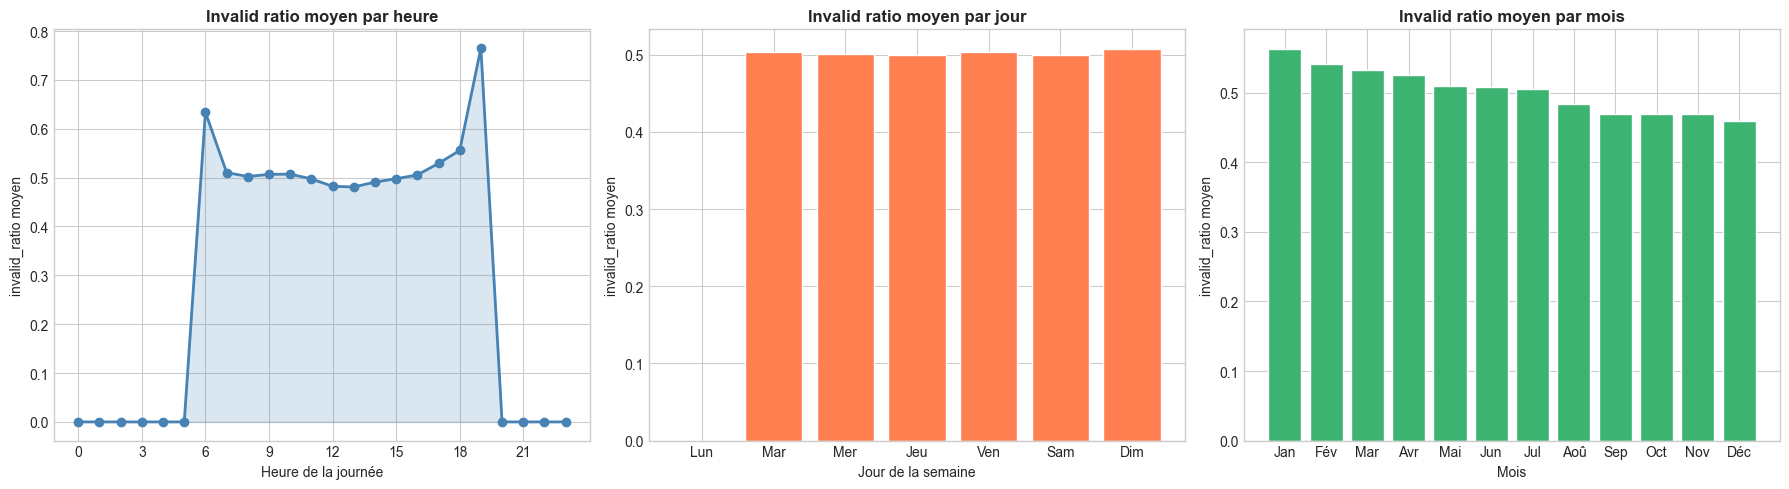

In [22]:
# Patterns temporels
df_eda = x_train.copy()
df_eda['invalid_ratio'] = y_train.values

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Par heure
hourly = df_eda.groupby('hour')['invalid_ratio'].mean().reindex(range(24), fill_value=0)
axes[0].plot(hourly.index, hourly.values, marker='o', linewidth=2, color='steelblue')
axes[0].fill_between(hourly.index, hourly.values, alpha=0.2, color='steelblue')
axes[0].set_title('Invalid ratio moyen par heure', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Heure de la journée')
axes[0].set_ylabel('invalid_ratio moyen')
axes[0].set_xticks(range(0, 24, 3))

# Par jour de la semaine
day_labels = ['Lun', 'Mar', 'Mer', 'Jeu', 'Ven', 'Sam', 'Dim']
daily = df_eda.groupby('day_of_week')['invalid_ratio'].mean().reindex(range(7), fill_value=0)
axes[1].bar(day_labels, daily.values, color='coral', edgecolor='white')
axes[1].set_title('Invalid ratio moyen par jour', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Jour de la semaine')
axes[1].set_ylabel('invalid_ratio moyen')

# Par mois
month_labels = ['Jan','Fév','Mar','Avr','Mai','Jun','Jul','Aoû','Sep','Oct','Nov','Déc']
monthly = df_eda.groupby('month_of_year')['invalid_ratio'].mean().reindex(range(1, 13), fill_value=0)
axes[2].bar(month_labels, monthly.values, color='mediumseagreen', edgecolor='white')
axes[2].set_title('Invalid ratio moyen par mois', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Mois')
axes[2].set_ylabel('invalid_ratio moyen')

plt.tight_layout()
plt.savefig('../DataViz/temporal_patterns.png', dpi=150, bbox_inches='tight')
plt.show()

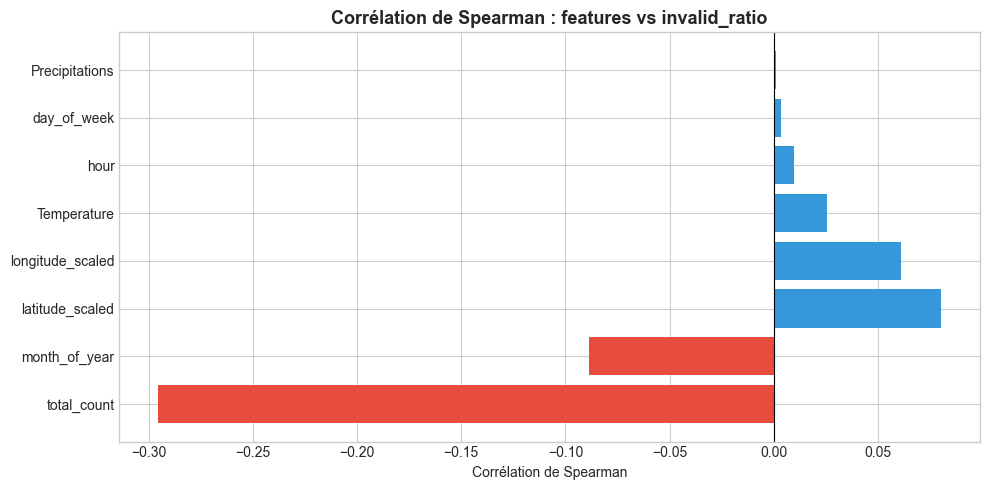

total_count        -0.2953
month_of_year      -0.0886
latitude_scaled     0.0802
longitude_scaled    0.0609
Temperature         0.0257
hour                0.0097
day_of_week         0.0034
Precipitations      0.0008
HauteurNeige           NaN
ForceVent              NaN
dtype: float64


In [23]:
# Corrélations de Spearman entre chaque feature et la cible
features = x_train.columns.tolist()
spearman_corrs = {}
for col in features:
    corr, pval = spearmanr(x_train[col], y_train)
    spearman_corrs[col] = corr

corr_df = pd.Series(spearman_corrs).sort_values(key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#e74c3c' if v < 0 else '#3498db' for v in corr_df.values]
ax.barh(corr_df.index, corr_df.values, color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Corrélation de Spearman : features vs invalid_ratio', fontsize=13, fontweight='bold')
ax.set_xlabel('Corrélation de Spearman')
plt.tight_layout()
plt.savefig('../DataViz/spearman_correlations.png', dpi=150, bbox_inches='tight')
plt.show()

print(corr_df.round(4))

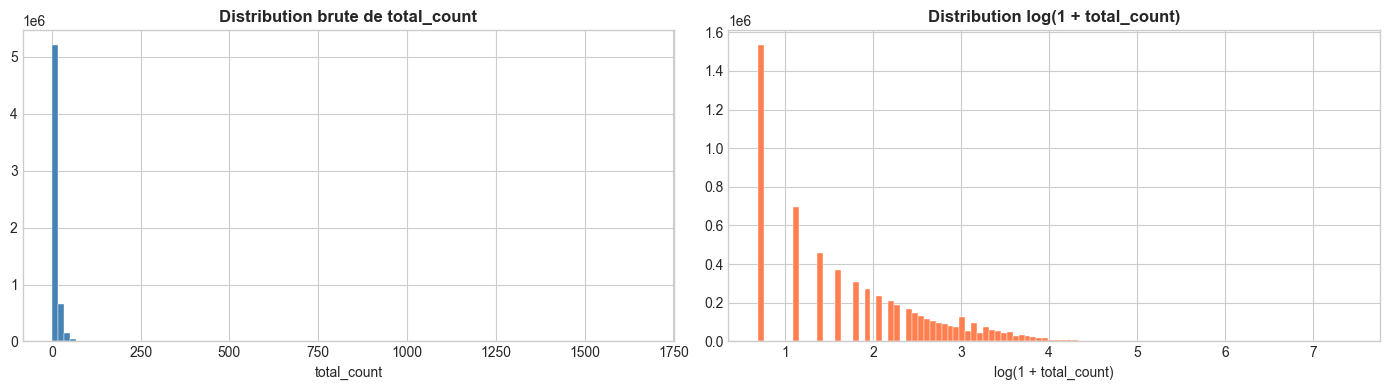

-----------------------------------
On remarque que la distribution brute de total_count est très skewed , on peut donc utiliser le log(1+x) pour la répartir correctement
Skewness brut     : 5.33
Skewness log+1    : 0.46


In [26]:
# Distribution de total_count — vérification du skew
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(x_train['total_count'], bins=100, color='steelblue', edgecolor='white', linewidth=0.3)
axes[0].set_title('Distribution brute de total_count', fontsize=12, fontweight='bold')
axes[0].set_xlabel('total_count')



log_count = np.log1p(x_train['total_count'])
axes[1].hist(log_count, bins=100, color='coral', edgecolor='white', linewidth=0.3)
axes[1].set_title('Distribution log(1 + total_count)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('log(1 + total_count)')

plt.tight_layout()
plt.savefig('../DataViz/total_count_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print("-----------------------------------")
print("On remarque que la distribution brute de total_count est très skewed , on peut donc utiliser le log(1+x) pour la répartir correctement")
print(f'Skewness brut     : {x_train["total_count"].skew():.2f}')
print(f'Skewness log+1    : {log_count.skew():.2f}')

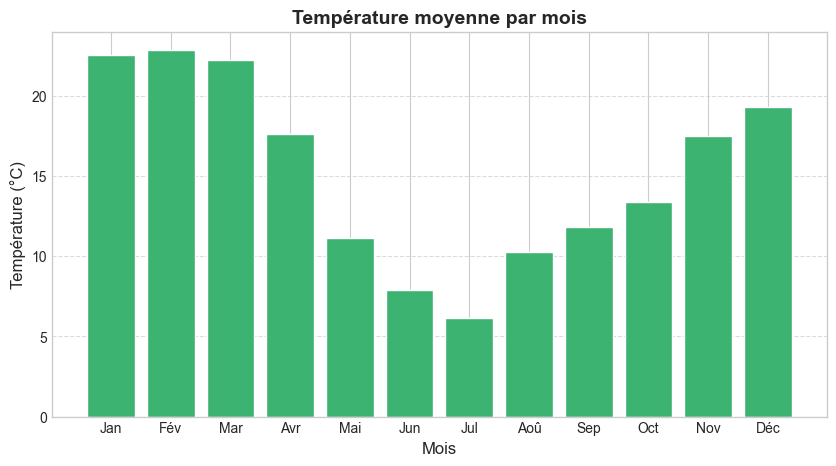

In [34]:
df_temp = x_train["Temperature"]

month_labels = ['Jan','Fév','Mar','Avr','Mai','Jun','Jul','Aoû','Sep','Oct','Nov','Déc']

# Moyenne par mois
monthly = x_train.groupby('month_of_year')['Temperature'].mean().reindex(range(1,13))

plt.figure(figsize=(10,5))
plt.bar(month_labels, monthly.values, color='mediumseagreen', edgecolor='white')
plt.title('Température moyenne par mois', fontsize=14, fontweight='bold')
plt.xlabel('Mois', fontsize=12)
plt.ylabel('Température (°C)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.savefig('../DataViz/Temperature_moyenne_par_mois.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Feature Engineering

In [43]:
from sklearn.cluster import KMeans


def engineer_features(df: pd.DataFrame) -> pd.DataFrame:
    """Ajoute des features dérivées au DataFrame."""
    df = df.copy()

    # --- Transformation cyclique des features temporelles ---
    # Permet au modèle de comprendre la continuité du temps (ex: heure 23 ≈ heure 0)
    df['hour_sin']  = np.sin(2 * np.pi * df['hour'] / 24)
    df['hour_cos']  = np.cos(2 * np.pi * df['hour'] / 24)
    df['day_sin']   = np.sin(2 * np.pi * df['day_of_week'] / 7)
    df['day_cos']   = np.cos(2 * np.pi * df['day_of_week'] / 7)
    df['month_sin'] = np.sin(2 * np.pi * df['month_of_year'] / 12)
    df['month_cos'] = np.cos(2 * np.pi * df['month_of_year'] / 12)
    
    # Heures importantes 
    df["is_morning_rush"] = df["hour"].apply(lambda x: 1 if x>=8 and x<=9 else 0)
    df["is_lunch"] = df["hour"].apply(lambda x: 1 if x>=12 and x<=14 else 0)
    df["is_evening"] = df["hour"].apply(lambda x: 1 if x>=17 else 0)
    
    # Week-End
    df["is_week_end"] = df["day_of_week"].apply(lambda x : 1 if x==5 or x==6 else 0)

    # --- Log-transform de total_count (très skewed) ---
    df['log_total_count'] = np.log1p(df['total_count']).astype('float32')
    
    # Température
    df["is_snowy"] = df["Temperature"].apply(lambda x: 1 if x<=0 else 0)
    df["is_cold"] = df["Temperature"].apply(lambda x: 1 if x>0 and x<=10 else 0)
    df["is_tempered"] = df["Temperature"].apply(lambda x: 1 if x>10 and x<=20 else 0)
    df["is_hot"] = df["Temperature"].apply(lambda x: 1 if x>20 and x<=30 else 0)
    df["is_very_hot"] = df["Temperature"].apply(lambda x: 1 if x>30 else 0 )
    
    
    # --- Features météo combinées ---
    # Sévérité météo globale
    df['weather_severity'] = (df['Precipitations'] + df['HauteurNeige'] * 0.3).astype('float32')
    # Interaction pluie × vent (conditions difficiles)
    df['wind_rain'] = (df['ForceVent'] * df['Precipitations']).astype('float32')
    # Présence de pluie (binaire)
    df['has_rain'] = (df['Precipitations'] > 0).astype('int8')

    # --- Saison (1=hiver, 2=printemps, 3=été, 4=automne) ---
    """ 
    winter = décembre, janvier, février
    spring = mars, avril, mai
    summer = juin, juillet, août
    autumn = septembre, octobre, novembre 
    
    """
    season_map = {12: 1, 1: 1, 2: 1, 3: 2, 4: 2, 5: 2,
                  6: 3, 7: 3, 8: 3, 9: 4, 10: 4, 11: 4}
    df['season'] = df['month_of_year'].map(season_map).astype('int8')
    
    # Groupement selon lat_scaled , long_scaled
    coords = df[['longitude_scaled','latitude_scaled']]
    kmeans = KMeans(n_clusters=3, random_state=SEED)
    
    df['geo_cluster'] = kmeans.fit_predict(coords)
    
    # Distance du centre 
    center = [df['latitude_scaled'].mean(), df['longitude_scaled'].mean()]
    df['dist_to_center'] = np.sqrt(
        (df['latitude_scaled'] - center[0])**2 +
        (df['longitude_scaled'] - center[1])**2
    )
    
    # Nan Values
    mean_value = df["ForceVent"].mean()
    df["ForceVent"].fillna(value=mean_value,inplace=True)
    
    # On remarque : La hauteur neige > 0 lorsque la temperature est en dessous de 2.7 degré
    df['HauteurNeige'] = df.apply(
        lambda row: 0 if pd.isna(row['HauteurNeige']) and row['Temperature'] > 2.7 else row['HauteurNeige'],
        axis=1
    )
    

    return df


print('Application du feature engineering...')
x_train_fe = engineer_features(x_train)
x_test_fe  = engineer_features(x_test)


Application du feature engineering...


In [44]:
x_train_fe

,total_count,longitude_scaled,latitude_scaled,Precipitations,HauteurNeige,Temperature,ForceVent,day_of_week,month_of_year,hour,...,is_cold,is_tempered,is_hot,is_very_hot,weather_severity,wind_rain,has_rain,season,geo_cluster,dist_to_center
0,1,0.998417,0.996118,0.0,0.0,14.6,2.5,3,4,8,...,0,1,0,0,0.0,0.00,0,2,2,0.000436
1,35,0.999222,0.996000,0.0,0.0,22.4,3.1,5,3,13,...,0,0,1,0,0.0,0.00,0,2,0,0.000386
2,3,0.998371,0.996309,1.8,0.0,11.7,3.3,4,10,8,...,0,1,0,0,1.8,5.94,1,4,2,0.000520
3,1,0.998804,0.996343,0.0,0.0,28.6,2.6,4,2,16,...,0,0,1,0,0.0,0.00,0,1,0,0.000234
4,2,0.999126,0.996417,0.0,0.0,9.6,3.2,3,9,18,...,1,0,0,0,0.0,0.00,0,4,0,0.000408
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6076541,9,0.998397,0.996100,0.0,0.0,-0.3,2.3,5,7,18,...,0,0,0,0,0.0,0.00,0,3,2,0.000456
6076542,55,0.998655,0.996093,0.0,0.0,17.0,6.0,6,12,10,...,0,1,0,0,0.0,0.00,0,1,2,0.000199
6076543,9,0.999200,0.996001,0.0,0.0,11.5,5.1,3,5,12,...,0,1,0,0,0.0,0.00,0,2,0,0.000364
6076544,14,0.998374,0.996076,0.0,0.0,13.6,3.5,4,11,7,...,0,1,0,0,0.0,0.00,0,4,2,0.000481


In [45]:
def remove_useless_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    
    columns = ["hour","day_of_week","month_of_year"]
    
    df = df.drop(columns=columns , axis=1)
    
    return df

x_train_fe = remove_useless_features(x_train_fe)
x_train_fe

,total_count,longitude_scaled,latitude_scaled,Precipitations,HauteurNeige,Temperature,ForceVent,hour_sin,hour_cos,day_sin,...,is_cold,is_tempered,is_hot,is_very_hot,weather_severity,wind_rain,has_rain,season,geo_cluster,dist_to_center
0,1,0.998417,0.996118,0.0,0.0,14.6,2.5,8.660254e-01,-5.000000e-01,0.433884,...,0,1,0,0,0.0,0.00,0,2,2,0.000436
1,35,0.999222,0.996000,0.0,0.0,22.4,3.1,-2.588190e-01,-9.659258e-01,-0.974928,...,0,0,1,0,0.0,0.00,0,2,0,0.000386
2,3,0.998371,0.996309,1.8,0.0,11.7,3.3,8.660254e-01,-5.000000e-01,-0.433884,...,0,1,0,0,1.8,5.94,1,4,2,0.000520
3,1,0.998804,0.996343,0.0,0.0,28.6,2.6,-8.660254e-01,-5.000000e-01,-0.433884,...,0,0,1,0,0.0,0.00,0,1,0,0.000234
4,2,0.999126,0.996417,0.0,0.0,9.6,3.2,-1.000000e+00,-1.836970e-16,0.433884,...,1,0,0,0,0.0,0.00,0,4,0,0.000408
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6076541,9,0.998397,0.996100,0.0,0.0,-0.3,2.3,-1.000000e+00,-1.836970e-16,-0.974928,...,0,0,0,0,0.0,0.00,0,3,2,0.000456
6076542,55,0.998655,0.996093,0.0,0.0,17.0,6.0,5.000000e-01,-8.660254e-01,-0.781831,...,0,1,0,0,0.0,0.00,0,1,2,0.000199
6076543,9,0.999200,0.996001,0.0,0.0,11.5,5.1,1.224647e-16,-1.000000e+00,0.433884,...,0,1,0,0,0.0,0.00,0,2,0,0.000364
6076544,14,0.998374,0.996076,0.0,0.0,13.6,3.5,9.659258e-01,-2.588190e-01,-0.433884,...,0,1,0,0,0.0,0.00,0,4,2,0.000481


In [46]:
FEATURES = x_train_fe.columns.tolist()
print(f'Nombre de features après engineering : {len(FEATURES)}')
print(FEATURES)

Nombre de features après engineering : 29
['total_count', 'longitude_scaled', 'latitude_scaled', 'Precipitations', 'HauteurNeige', 'Temperature', 'ForceVent', 'hour_sin', 'hour_cos', 'day_sin', 'day_cos', 'month_sin', 'month_cos', 'is_morning_rush', 'is_lunch', 'is_evening', 'is_week_end', 'log_total_count', 'is_snowy', 'is_cold', 'is_tempered', 'is_hot', 'is_very_hot', 'weather_severity', 'wind_rain', 'has_rain', 'season', 'geo_cluster', 'dist_to_center']


In [52]:
x_train_fe.sort_values(by=["total_count"] , ascending=True).head(20)

# BIZARRE EN ETE IL FAIT LE MOINS CHAUD ?????????

,total_count,longitude_scaled,latitude_scaled,Precipitations,HauteurNeige,Temperature,ForceVent,hour_sin,hour_cos,day_sin,...,is_cold,is_tempered,is_hot,is_very_hot,weather_severity,wind_rain,has_rain,season,geo_cluster,dist_to_center
3870184,1,0.999066,0.996506,0.0,0.0,32.9,0.7,-8.660254e-01,-5.000000e-01,-0.433884,...,0,0,0,1,0.0,0.00,0,2,0,0.000446
60,1,0.998988,0.996492,0.0,0.0,5.6,4.8,-5.000000e-01,-8.660254e-01,-0.433884,...,1,0,0,0,0.0,0.00,0,3,0,0.000401
59,1,0.998294,0.996016,0.6,0.0,10.5,8.2,7.071068e-01,-7.071068e-01,0.974928,...,0,1,0,0,0.6,4.92,1,3,2,0.000568
6076512,1,0.999274,0.996649,0.0,0.0,21.2,1.2,-8.660254e-01,-5.000000e-01,-0.974928,...,0,0,1,0,0.0,0.00,0,2,0,0.000680
6076509,1,0.999296,0.996463,0.0,0.0,28.4,2.1,-2.588190e-01,-9.659258e-01,0.781831,...,0,0,1,0,0.0,0.00,0,1,0,0.000564
48,1,0.998898,0.996387,0.0,0.0,22.3,1.9,-9.659258e-01,-2.588190e-01,0.433884,...,0,0,1,0,0.0,0.00,0,2,0,0.000276
44,1,0.998491,0.995826,0.0,0.0,17.7,3.2,-8.660254e-01,-5.000000e-01,0.781831,...,0,1,0,0,0.0,0.00,0,4,2,0.000463
6076535,1,0.998471,0.996179,0.0,0.0,19.3,3.1,5.000000e-01,-8.660254e-01,-0.433884,...,0,1,0,0,0.0,0.00,0,1,2,0.000388
3192668,1,0.998734,0.995951,0.2,0.0,10.8,2.2,-1.000000e+00,-1.836970e-16,0.974928,...,0,1,0,0,0.2,0.44,1,3,2,0.000202
3192665,1,0.999339,0.996619,0.0,0.0,27.6,1.9,-2.588190e-01,-9.659258e-01,0.781831,...,0,0,1,0,0.0,0.00,0,1,0,0.000700


## 4. Stratégie de modélisation

In [ ]:
# Paramètres LightGBM optimisés
lgb_params = {
    'objective': 'regression_l1',   # MAE robuste aux outliers
    'metric': 'mae',
    'n_estimators': 3000,
    'learning_rate': 0.0517583972538538,
    'num_leaves': 237,
    'feature_fraction': 0.7429819565111431,
    'bagging_fraction': 0.8484403473505087,
    'bagging_freq': 6,
    'min_child_samples': 50,
    'lambda_l1': 3.2295487420726103,
    'lambda_l2': 3.744628140786851,
    'n_jobs': -1,
    'verbose': -1,
    'random_state': SEED,
}

print('Paramètres LightGBM définis ✓')


Paramètres LightGBM définis ✓


In [53]:
# Validation croisée 5 folds
kf = KFold(n_splits=5, shuffle=True, random_state=SEED)

oof_preds = np.zeros(len(x_train_fe))    # Out-of-fold predictions
test_preds = np.zeros(len(x_test_fe))    # Prédictions sur le test
fold_scores = []

X = x_train_fe[FEATURES].values
y = y_train 
X_test = x_test_fe[FEATURES].values

print(f'Entraînement en {kf.n_splits} folds...')
print('─' * 60)

for fold, (train_idx, val_idx) in enumerate(kf.split(X, y), 1):
    X_tr, X_val = X[train_idx], X[val_idx]
    y_tr, y_val = y[train_idx], y[val_idx]
    y_val_orig = y_train.values[val_idx]  # valeurs originales pour Spearman

    model = lgb.LGBMRegressor(**lgb_params)
    model.fit(
        X_tr, y_tr,
        eval_set=[(X_val, y_val)],
        callbacks=[
            lgb.early_stopping(stopping_rounds=100, verbose=False),
            lgb.log_evaluation(period=-1)
        ]
    )

    val_pred = model.predict(X_val)
    oof_preds[val_idx] = val_pred
    test_preds += model.predict(X_test) / kf.n_splits

    # Spearman entre prédictions et valeurs originales (pas les rangs)
    score = spearmanr(y_val_orig, val_pred).correlation
    fold_scores.append(score)
    print(f'  Fold {fold} | best_iter={model.best_iteration_:4d} | Spearman = {score:.4f}')

print('─' * 60)
oof_score = spearmanr(y_train.values, oof_preds).correlation
print(f'  OOF global        | Spearman = {oof_score:.4f}')
print(f'  Moyenne des folds | Spearman = {np.mean(fold_scores):.4f} ± {np.std(fold_scores):.4f}')

Entraînement en 5 folds...
────────────────────────────────────────────────────────────
  Fold 1 | best_iter=3000 | Spearman = 0.5839
  Fold 2 | best_iter=3000 | Spearman = 0.5826
  Fold 3 | best_iter=3000 | Spearman = 0.5829
  Fold 4 | best_iter=3000 | Spearman = 0.5799
  Fold 5 | best_iter=3000 | Spearman = 0.5830
────────────────────────────────────────────────────────────
  OOF global        | Spearman = 0.5825
  Moyenne des folds | Spearman = 0.5825 ± 0.0014


## 5. Optimisation des hyperparamètres 

## 6. Analyse & Interprétabilité

## 7. Prédictions & Soumission

In [56]:
# Formatage de la soumission
submission = pd.DataFrame({
    'invalid_ratio': test_preds
}, index=x_test.index)

# Clipping pour s'assurer que les valeurs restent dans [0, 1]
submission['invalid_ratio'] = submission['invalid_ratio'].clip(0, 1)

print(f'Nombre de prédictions : {len(submission)}')
print(f'Valeurs manquantes    : {submission.isnull().sum().sum()}')
print(f'Min prédit            : {submission["invalid_ratio"].min():.4f}')
print(f'Max prédit            : {submission["invalid_ratio"].max():.4f}')
print(f'Moyenne prédite       : {submission["invalid_ratio"].mean():.4f}')

submission.to_csv('../output/y_test_predictions.csv')
print('\nFichier de soumission sauvegardé : outputs/y_test_predictions.csv ✓')
display(submission.head(10))

Nombre de prédictions : 2028750
Valeurs manquantes    : 0
Min prédit            : 0.0000
Max prédit            : 1.0000
Moyenne prédite       : 0.6000

Fichier de soumission sauvegardé : outputs/y_test_predictions.csv ✓


,invalid_ratio
0,0.906667
1,0.439378
2,0.916228
3,0.350881
4,0.600031
5,0.000000
6,0.767146
7,0.748939
8,0.551493
9,0.383663
